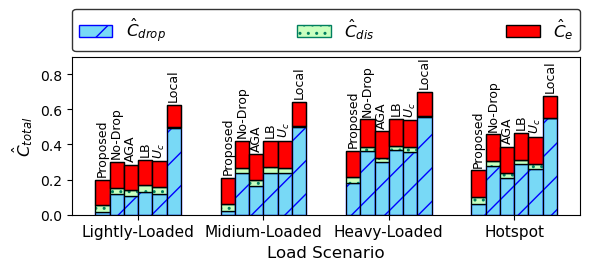

Saved to:
  Graphs_for_paper/sweep_load_breakdown_all_approaches_paper.pdf
  Graphs_for_paper/sweep_load_breakdown_all_approaches_paper.png


In [1]:
import os
import subprocess
import matplotlib.pyplot as plt
import numpy as np

from read_config import get_config

# %matplotlib inline   # uncomment if needed

CFG = get_config()
PSI_D = CFG['PSI_DROP']
PSI_I = CFG['PSI_DIS']
PSI_E = CFG['PSI_E']

OUT = 'Graphs_for_paper'
os.makedirs(OUT, exist_ok=True)

ALGO_ORDER = ['Proposed', 'NO_DROP', 'AGA', 'LB', 'Uc', 'LOCAL']

# Paper display names
METHOD_NAME_MAPPING = {
    'Proposed': 'Proposed',
    'NO_DROP': 'No-Drop',
    'AGA': 'AGA',
    'LB': 'LB',
    'Uc': r'$U_c$',
    'LOCAL': 'Local'
}

def run_cmd(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=120)
    if r.returncode != 0:
        raise RuntimeError(f"Command failed:\n{cmd}\n\nstderr:\n{r.stderr}")
    return r.stdout.strip()

def parse_line(line):
    p = line.strip().split(',')
    if len(p) < 4:
        return None
    d = {
        'name': p[0],
        'C_drop': float(p[1]),
        'C_dis': float(p[2]),
        'C_energy': float(p[3]),
    }
    if len(p) >= 9:
        d.update({
            'H_done': int(p[4]),
            'H_drop': int(p[6]),
            'S_drop': int(p[7]),
        })
    return d

def run_all(datafile, d_hop, pidle, pmax, umax):
    """
    Same algorithm execution pattern as sweep_param.py
    """
    results = {}
    power_flags = f'--pidle {pidle} --pmax {pmax} --umax {umax}'

    for algo, binary in [('Proposed', 'proposed'), ('NO_DROP', 'no_drop')]:
        out = run_cmd(f'bin/{binary} {datafile} {d_hop} --detailed {power_flags}')
        for line in out.split('\n'):
            d = parse_line(line)
            if d:
                results[d['name']] = d

    for algo, binary in [('AGA', 'aga'), ('LB', 'lb'), ('Uc', 'uc'), ('LOCAL', 'local_only')]:
        out = run_cmd(f'bin/{binary} {datafile} --detailed {power_flags}')
        for line in out.split('\n'):
            d = parse_line(line)
            if d:
                results[d['name']] = d

    return results

def parse_results_csv(filename):
    """
    Same CSV style as make_all_graphs.py
    """
    data = {}
    with open(filename) as f:
        for line in f:
            p = line.strip().split(',')
            if len(p) < 4:
                continue
            data[p[0]] = {
                'C_drop': float(p[1]),
                'C_dis': float(p[2]),
                'C_energy': float(p[3]),
            }
            if len(p) >= 9:
                data[p[0]].update({
                    'H_done': int(p[4]),
                    'S_done': int(p[5]),
                    'H_drop': int(p[6]),
                    'S_drop': int(p[7]),
                    'AvgUtil': float(p[8]),
                })
    return data

# ------------------------------------------------------------
# Pull values from the SAME places as the uploaded scripts
# ------------------------------------------------------------

scenario_defs = [
    #('Light\n(30 AVs)',              30, {}),
    ('Lightly-Loaded',          50, {}),
    ('Midium-Loaded',                80, {}),
    ('Heavy-Loaded',            120, {}),
    ('Hotspot', 80, {'HOTSPOT_PROB': 0.80, 'HOTSPOT_CLUSTER': 0.60, 'HOTSPOT_RADIUS': 20}),
]

all_data = {}

for label, nav, hotspot_overrides in scenario_defs:
    tmpfile = f'/tmp/load_breakdown_{label.split(chr(10))[0].lower().replace(" ","_")}.txt'

    if hotspot_overrides:
        import shutil
        tmp_cfg = '/tmp/hotspot_load_cfg.txt'
        shutil.copy('config.txt', tmp_cfg)
        with open(tmp_cfg, 'a') as f:
            for k, v in hotspot_overrides.items():
                f.write(f'\n{k} = {v}\n')
        run_cmd(f'bin/gen_data {nav} 10 {CFG["SIM_MS"]} {tmpfile} {tmp_cfg}')
    else:
        run_cmd(f'bin/gen_data {nav} 10 {CFG["SIM_MS"]} {tmpfile}')

    results = run_all(
        datafile=tmpfile,
        d_hop=CFG['DIS_HOP'],
        pidle=CFG['P_IDLE'],
        pmax=CFG['P_MAX'],
        umax=CFG['MAX_UTIL']
    )

    weighted = {}
    for algo in ALGO_ORDER:
        if algo in results:
            d = results[algo]
            weighted[algo] = {
                'Drop': PSI_D * d['C_drop'],
                'Dis': PSI_I * d['C_dis'],
                'Energy': PSI_E * d['C_energy'],
            }
    all_data[label] = weighted

# ------------------------------------------------------------
# Plot: grouped stacked bars for ALL approaches
# ------------------------------------------------------------

cost_mapping = {
    'Drop': r'$\hat{C}_{drop}$',
    'Dis': r'$\hat{C}_{dis}$',
    'Energy': r'$\hat{C}_{e}$'
}

colors = {
    r'$\hat{C}_{drop}$': '#78d9f6',
    r'$\hat{C}_{dis}$': '#caffbf',
    r'$\hat{C}_{e}$': 'red'
}

hatch_patterns = {
    r'$\hat{C}_{drop}$': '/',
    r'$\hat{C}_{dis}$': '..',
    r'$\hat{C}_{e}$': ''
}

edge_colors = {
    r'$\hat{C}_{drop}$': 'blue',
    r'$\hat{C}_{dis}$': '#007f5f',
    r'$\hat{C}_{e}$': '#000000'
}

scenario_labels = list(all_data.keys())
num_scenarios = len(scenario_labels)
num_methods = len(ALGO_ORDER)

fig, ax = plt.subplots(figsize=(6, 3))

bar_width = 0.10
group_spacing = 0.28
index = np.arange(num_scenarios) * (num_methods * bar_width + group_spacing)

legend_added = {'Drop': False, 'Dis': False, 'Energy': False}

for i, scenario in enumerate(scenario_labels):
    methods = all_data[scenario]

    for j, method in enumerate(ALGO_ORDER):
        if method not in methods:
            continue

        costs = methods[method]
        x_pos = index[i] + j * bar_width
        bottom = 0.0

        for raw_key in ['Drop', 'Dis', 'Energy']:
            val = costs[raw_key]
            cost_label = cost_mapping[raw_key]

            label = cost_label if not legend_added[raw_key] else ""
            ax.bar(
                x_pos, val, bar_width, bottom=bottom,
                color=colors[cost_label],
                hatch=hatch_patterns[cost_label],
                edgecolor=edge_colors[cost_label],
                linewidth=1.0,
                label=label
            )
            ax.bar(
                x_pos, val, bar_width, bottom=bottom,
                color='none',
                edgecolor='k',
                linewidth=0.8
            )
            legend_added[raw_key] = True
            bottom += val

        ax.text(
            x_pos,
            bottom + max(0.02, 0.01 * bottom),
            METHOD_NAME_MAPPING.get(method, method),
            ha='center',
            va='bottom',
            rotation=90,
            fontsize=9
        )

ax.set_xlabel('Load Scenario', fontsize=12)
ax.set_ylabel(r'$\hat{C}_{total}$', fontsize=12)
#ax.set_title('Cost Breakdown vs Load Scenario')

ax.set_xticks(index + (num_methods - 1) * bar_width / 2)
ax.set_xticklabels(scenario_labels, fontsize=11)
ax.set_ylim(0, 0.9)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    fontsize=12,
    bbox_to_anchor=(0, 1.1, 1, 0.2),
    loc='upper left',
    mode='expand',
    borderaxespad=0,
    ncol=3,
    edgecolor='k'
)

plt.subplots_adjust(top=0.85)
plt.tight_layout()

plt.savefig(f'{OUT}/sweep_load_breakdown_all_approaches_paper.pdf', bbox_inches='tight')
plt.savefig(f'{OUT}/sweep_load_breakdown_all_approaches_paper.png', bbox_inches='tight', dpi=300)
plt.show()

print("Saved to:")
print(f"  {OUT}/sweep_load_breakdown_all_approaches_paper.pdf")
print(f"  {OUT}/sweep_load_breakdown_all_approaches_paper.png")

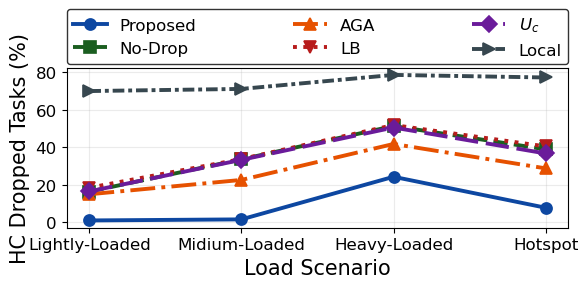

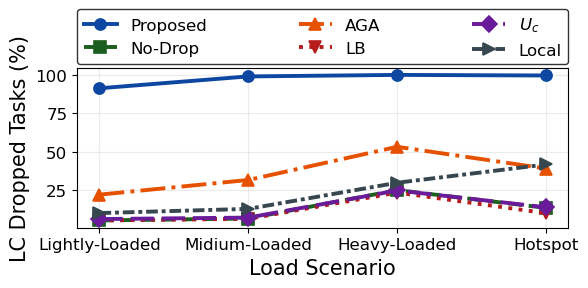

In [2]:
import os
import shutil
import subprocess
import matplotlib.pyplot as plt
import numpy as np
from read_config import get_config

CFG = get_config()
OUT = 'Graphs_for_paper'
os.makedirs(OUT, exist_ok=True)

ALGO_ORDER = ['Proposed', 'NO_DROP', 'AGA', 'LB', 'Uc', 'LOCAL']

DISPLAY_NAMES = {
    'Proposed': 'Proposed',
    'NO_DROP': 'No-Drop',
    'AGA': 'AGA',
    'LB': 'LB',
    'Uc': r'$U_c$',
    'LOCAL': 'Local'
}

LINE_COLORS = {
    'Proposed': '#0D47A1',
    'NO_DROP': '#1B5E20',
    'AGA': '#E65100',
    'LB': '#B71C1C',
    'Uc': '#6A1B9A',
    'LOCAL': '#37474F'
}

LINE_STYLES = {
    'Proposed': '-',
    'NO_DROP': '--',
    'AGA': '-.',
    'LB': ':',
    'Uc': (0, (6, 2)),
    'LOCAL': (0, (3, 1, 1, 1))
}

MARKERS = {
    'Proposed': 'o',
    'NO_DROP': 's',
    'AGA': '^',
    'LB': 'v',
    'Uc': 'D',
    'LOCAL': '>'
}

def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=120)
    if r.returncode != 0:
        raise RuntimeError(f"Command failed:\n{cmd}\n\nstderr:\n{r.stderr}")
    return r.stdout.strip()

def count_tasks(datafile):
    with open(datafile, 'r') as f:
        lines = f.readlines()

    m = int(lines[0].strip())
    task_lines = lines[1 + m:]

    hc, lc = 0, 0
    for line in task_lines:
        parts = line.strip().split()
        if len(parts) >= 4:
            if int(parts[3]) == 0:
                hc += 1
            else:
                lc += 1
    return hc, lc

def parse_line(line):
    p = line.strip().split(',')
    if len(p) < 4:
        return None

    d = {
        'name': p[0],
        'C_drop': float(p[1]),
        'C_dis': float(p[2]),
        'C_energy': float(p[3]),
    }

    if len(p) >= 9:
        d.update({
            'H_done': int(p[4]),
            'S_done': int(p[5]),
            'H_drop': int(p[6]),
            'S_drop': int(p[7]),
        })

    return d

def run_all(datafile, d_hop, pidle, pmax, umax):
    results = {}
    power_flags = f'--pidle {pidle} --pmax {pmax} --umax {umax}'

    for _, binary in [('Proposed', 'proposed'), ('NO_DROP', 'no_drop')]:
        out = run(f'bin/{binary} {datafile} {d_hop} --detailed {power_flags}')
        for line in out.split('\n'):
            d = parse_line(line)
            if d:
                results[d['name']] = d

    for _, binary in [('AGA', 'aga'), ('LB', 'lb'), ('Uc', 'uc'), ('LOCAL', 'local_only')]:
        out = run(f'bin/{binary} {datafile} --detailed {power_flags}')
        for line in out.split('\n'):
            d = parse_line(line)
            if d:
                results[d['name']] = d

    return results

scenarios = [
    #('Light\n(30 AVs)',              30, {}),
    ('Lightly-Loaded',          50, {}),
    ('Midium-Loaded',                80, {}),
    ('Heavy-Loaded',            120, {}),
    ('Hotspot', 80, {'HOTSPOT_PROB': 0.80, 'HOTSPOT_CLUSTER': 0.60, 'HOTSPOT_RADIUS': 20}),

]

scenario_labels = []
hc_drop_pct = {algo: [] for algo in ALGO_ORDER}
lc_drop_pct = {algo: [] for algo in ALGO_ORDER}

for idx, (label, nav, hotspot) in enumerate(scenarios):
    scenario_labels.append(label)
    tmpfile = f'/tmp/drop_pct_lines_{idx}_{nav}.txt'

    if hotspot:
        cfgfile = f'/tmp/drop_pct_lines_cfg_{idx}.txt'
        shutil.copy('config.txt', cfgfile)
        with open(cfgfile, 'a') as f:
            for k, v in hotspot.items():
                f.write(f'\n{k} = {v}\n')
        run(f'bin/gen_data {nav} 10 10000 {tmpfile} {cfgfile}')
    else:
        run(f'bin/gen_data {nav} 10 10000 {tmpfile}')

    hc_total, lc_total = count_tasks(tmpfile)

    results = run_all(
        datafile=tmpfile,
        d_hop=CFG['DIS_HOP'],
        pidle=CFG['P_IDLE'],
        pmax=CFG['P_MAX'],
        umax=CFG['MAX_UTIL']
    )

    for algo in ALGO_ORDER:
        d = results.get(algo, {})
        h_drop = d.get('H_drop', 0)
        s_drop = d.get('S_drop', 0)

        hc_pct = 100.0 * h_drop / hc_total if hc_total > 0 else np.nan
        lc_pct = 100.0 * s_drop / lc_total if lc_total > 0 else np.nan

        hc_drop_pct[algo].append(hc_pct)
        lc_drop_pct[algo].append(lc_pct)

x = np.arange(len(scenario_labels))

# HC plot
plt.figure(figsize=(6, 3))
for algo in ALGO_ORDER:
    plt.plot(
        x,
        hc_drop_pct[algo],
        label=DISPLAY_NAMES[algo],
        color=LINE_COLORS[algo],
        linestyle=LINE_STYLES[algo],
        marker=MARKERS[algo],
        linewidth=2.8,
        markersize=8,
        markeredgewidth=1.2
    )

#plt.title('HC Dropped Task Percentage vs Load Scenario', fontsize=18)
plt.xlabel('Load Scenario', fontsize=15)
plt.ylabel('HC Dropped Tasks (%)', fontsize=15)
plt.xticks(x, scenario_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.25, linewidth=0.8)

plt.legend(
    fontsize=12,
    ncol=3,
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc='lower left',
    mode='expand',
    borderaxespad=0,
    frameon=True,
    edgecolor='k'
)

plt.subplots_adjust(top=0.82)
plt.tight_layout()
plt.savefig(f'{OUT}/hc_drop_percentage_vs_load.pdf', bbox_inches='tight')
plt.savefig(f'{OUT}/hc_drop_percentage_vs_load.png', bbox_inches='tight', dpi=300)
plt.show()

# LC plot
plt.figure(figsize=(6, 3))
for algo in ALGO_ORDER:
    plt.plot(
        x,
        lc_drop_pct[algo],
        label=DISPLAY_NAMES[algo],
        color=LINE_COLORS[algo],
        linestyle=LINE_STYLES[algo],
        marker=MARKERS[algo],
        linewidth=2.8,
        markersize=8,
        markeredgewidth=1.2
    )

#plt.title('LC Dropped Task Percentage vs Load Scenario', fontsize=18)
plt.xlabel('Load Scenario', fontsize=15)
plt.ylabel('LC Dropped Tasks (%)', fontsize=15)
plt.xticks(x, scenario_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.25, linewidth=0.8)

plt.legend(
    fontsize=12,
    ncol=3,
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc='lower left',
    mode='expand',
    borderaxespad=0,
    frameon=True,
    edgecolor='k'
)

plt.subplots_adjust(top=0.82)
plt.tight_layout()
plt.savefig(f'{OUT}/lc_drop_percentage_vs_load.pdf', bbox_inches='tight')
plt.savefig(f'{OUT}/lc_drop_percentage_vs_load.png', bbox_inches='tight', dpi=300)
plt.show()

In [3]:
#!/usr/bin/env python3
"""Box plots: (A) Per-BS average utilization, (B) Per-task distance.
Reads DIST:/UTIL: lines from --stats output of each algorithm.
Notebook-safe version.
"""
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import os

OUT = 'Graphs_for_paper'
os.makedirs(OUT, exist_ok=True)

# IMPORTANT: set this manually in notebook
datafile = 'data/80av_10bs.txt'

METHOD_ORDER = [
    ('Proposed', 'proposed', True),
    ('NO_DROP',  'no_drop',  True),
    ('LOCAL',    'local_only', False),
    ('AGA',      'aga',      False),
    ('LB',       'lb',       False),
    ('Uc',       'uc',       False)
]
LABELS = ['Proposed', 'No-Drop', 'Local', 'AGA', 'LB', '$U_c$']

util_data = {}
dist_data = {}

def run_cmd(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=120)
    if r.returncode != 0:
        raise RuntimeError(f"Command failed:\n{cmd}\n\nstderr:\n{r.stderr}")
    return r.stdout.strip()

for name, binary, needs_args in METHOD_ORDER:
    if needs_args:
        cmd = f'bin/{binary} {datafile} 10 --detailed --stats'
    else:
        cmd = f'bin/{binary} {datafile} --detailed --stats'

    out = run_cmd(cmd)

    for line in out.split('\n'):
        if line.startswith('DIST:'):
            parts = line.split(':', 2)
            vals = [float(x) for x in parts[2].split(',') if x]
            dist_data[name] = vals
        elif line.startswith('UTIL:'):
            parts = line.split(':', 2)
            vals = [float(x) for x in parts[2].split(',') if x]
            util_data[name] = vals

    print(f"  {name}: {len(dist_data.get(name,[]))} tasks, {len(util_data.get(name,[]))} BSs")

def make_boxplot_bxp(data_dict, order, labels, ylabel, xlabel, filename):
    """Use ax.bxp() with precomputed stats, matching reference style."""
    box_data = []
    for i, (name, _, _) in enumerate(order):
        vals = data_dict.get(name, [])
        if not vals:
            box_data.append({
                'label': labels[i], 'whislo': 0, 'q1': 0,
                'med': 0, 'q3': 0, 'whishi': 0
            })
            continue

        arr = np.array(vals)
        q1, med, q3 = np.percentile(arr, [25, 50, 75])
        iqr = q3 - q1
        whislo = max(arr.min(), q1 - 1.5 * iqr)
        whishi = min(arr.max(), q3 + 1.5 * iqr)

        box_data.append({
            'label': labels[i],
            'whislo': whislo,
            'q1': q1,
            'med': med,
            'q3': q3,
            'whishi': whishi,
        })

    fig, ax = plt.subplots(figsize=(6, 3))
    bp = ax.bxp(box_data, showfliers=False, patch_artist=True)

    colors = ['#5DADE2', '#82E0AA', '#F8C471', '#F5B7B1',
              '#C39BD3', '#AED6F1']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.8)

    for median in bp['medians']:
        median.set_color('#C62828')
        median.set_linewidth(2.6)

    for whisker in bp['whiskers']:
        whisker.set_color('#333333')
        whisker.set_linewidth(1.7)

    for cap in bp['caps']:
        cap.set_color('#333333')
        cap.set_linewidth(1.7)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.tick_params(axis='both', labelsize=10)

    plt.tight_layout()
    plt.savefig(f'{OUT}/{filename}.pdf', bbox_inches='tight')
    plt.savefig(f'{OUT}/{filename}.png', bbox_inches='tight', dpi=300)
    plt.close()
    print(f"  Saved: {OUT}/{filename}.pdf")

# Normalize distances to [0,1] using grid diagonal
GRID = 200
diagonal = GRID * np.sqrt(2)
dist_norm = {}
for name in dist_data:
    dist_norm[name] = [d / diagonal for d in dist_data[name]]

print("\nGenerating box plots...")
make_boxplot_bxp(util_data, METHOD_ORDER, LABELS,
    r'Average utilization per BS', 'Approaches',
    'fig_boxplot_util')

make_boxplot_bxp(dist_norm, METHOD_ORDER, LABELS,
    r'Normalized $\hat{C}_{dis}$ per task', 'Approaches',
    'fig_boxplot_distance')

print("Done.")

  Proposed: 8279 tasks, 10 BSs
  NO_DROP: 7597 tasks, 10 BSs
  LOCAL: 4905 tasks, 10 BSs
  AGA: 7614 tasks, 10 BSs
  LB: 7998 tasks, 10 BSs
  Uc: 7959 tasks, 10 BSs

Generating box plots...
  Saved: Graphs_for_paper/fig_boxplot_util.pdf
  Saved: Graphs_for_paper/fig_boxplot_distance.pdf
Done.


  Generating output/80av_10bs_results.csv ...
  Done: output/80av_10bs_results.csv


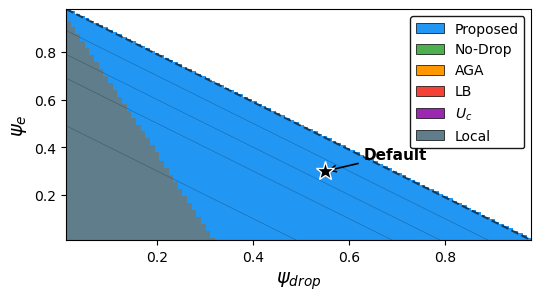

Fig C: ψ heatmap ✓


In [4]:
%matplotlib inline
import subprocess, os
import matplotlib.pyplot as plt
import numpy as np
from read_config import get_config

_CFG = get_config()
OUT = 'Graphs_for_paper/'
os.makedirs(OUT, exist_ok=True)
os.makedirs('output', exist_ok=True)

ALGOS = ['Proposed', 'NO_DROP', 'AGA', 'LB', 'Uc', 'LOCAL']
LABELS = {'Proposed': 'Proposed', 'NO_DROP': 'No-Drop', 'AGA': 'AGA',
          'LB': 'LB', 'Uc': '$U_c$', 'LOCAL': 'Local'}
COLORS = {'Proposed': '#2196F3', 'NO_DROP': '#4CAF50', 'AGA': '#FF9800',
          'LB': '#F44336', 'Uc': '#9C27B0', 'LOCAL': '#607D8B'}

def run_cmd(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=120)
    return r.stdout.strip()

def parse_csv(filename):
    data = {}
    with open(filename) as f:
        for line in f:
            p = line.strip().split(',')
            if len(p) < 4:
                continue
            data[p[0]] = {'C_drop': float(p[1]), 'C_dis': float(p[2]), 'C_energy': float(p[3])}
            if len(p) >= 9:
                data[p[0]].update({'H_done': int(p[4]), 'H_drop': int(p[6])})
    return data

def generate_results_csv(scenario, datafile):
    outfile = f'output/{scenario}_results.csv'
    if os.path.exists(outfile):
        return
    print(f"  Generating {outfile} ...")
    lines = []
    for algo, binary in [('Proposed', 'proposed'), ('NO_DROP', 'no_drop')]:
        out = run_cmd(f'bin/{binary} {datafile} {_CFG["DIS_HOP"]} --detailed')
        if out:
            lines.append(out)
    for algo, binary in [('AGA', 'aga'), ('LB', 'lb'), ('Uc', 'uc'), ('LOCAL', 'local_only')]:
        out = run_cmd(f'bin/{binary} {datafile} --detailed')
        if out:
            lines.append(out)
    with open(outfile, 'w') as f:
        for l in lines:
            for line in l.split('\n'):
                if line.strip():
                    f.write(line.strip() + '\n')
    print(f"  Done: {outfile}")

# ════════════════════════════════════════════════════════════
# FIGURE C: Heatmap (ψ_drop vs ψ_e, ψ_dis = 1-both)
# ════════════════════════════════════════════════════════════
sc = '80av_10bs'
csv_path = f'output/{sc}_results.csv'
if not os.path.exists(csv_path):
    generate_results_csv(sc, 'data/80av_10bs.txt')

data = parse_csv(csv_path)

if data:
    from matplotlib.colors import ListedColormap, BoundaryNorm
    import matplotlib.patches as mpatches

    resolution = 100
    wd_range = np.linspace(0.01, 0.98, resolution)
    we_range = np.linspace(0.01, 0.98, resolution)

    win_grid = np.full((resolution, resolution), np.nan)
    algo_to_id = {a: i for i, a in enumerate(ALGOS)}

    for i, wd in enumerate(wd_range):
        for j, we in enumerate(we_range):
            wi = 1.0 - wd - we
            if wi < 0.01:
                continue
            best_algo = None
            best_cost = 1e9
            for algo in ALGOS:
                if algo not in data:
                    continue
                d = data[algo]
                ct = wd * d['C_drop'] + wi * d['C_dis'] + we * d['C_energy']
                if ct < best_cost:
                    best_cost = ct
                    best_algo = algo
            win_grid[j, i] = algo_to_id.get(best_algo, np.nan)

    fig, ax = plt.subplots(figsize=(6, 3))

    cmap = ListedColormap([COLORS[a] for a in ALGOS])
    bounds = np.arange(-0.5, len(ALGOS), 1)
    norm = BoundaryNorm(bounds, cmap.N)
    masked_win = np.ma.masked_invalid(win_grid)

    ax.imshow(masked_win, origin='lower', aspect='auto',
              cmap=cmap, norm=norm,
              extent=[wd_range[0], wd_range[-1],
                      we_range[0], we_range[-1]],
              interpolation='nearest')

    ax.plot([0.01, 0.98], [0.98, 0.01], 'k--', linewidth=1.5, alpha=0.6)

    ax.plot(_CFG['PSI_DROP'], _CFG['PSI_E'], 'k*',
            markersize=14, markeredgecolor='white', markeredgewidth=1.0,
            zorder=10)
    ax.annotate('Default', xy=(_CFG['PSI_DROP'], _CFG['PSI_E']),
                xytext=(_CFG['PSI_DROP'] + 0.08, _CFG['PSI_E'] + 0.05),
                fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

    for psi_dis_val in [0.1, 0.2, 0.3, 0.5]:
        x_end = 1.0 - psi_dis_val - 0.01
        y_start = 1.0 - psi_dis_val - 0.01
        if x_end > 0.05 and y_start > 0.05:
            ax.plot([0.01, x_end], [y_start, 0.01],
                    'k-', linewidth=0.4, alpha=0.3)
            #ax.text(x_end - 0.02, 0.03,
                    #f'$\\psi_{{dis}}$={psi_dis_val}',
                    #fontsize=6, alpha=0.5, rotation=0)

    ax.set_xlabel('$\\psi_{drop}$', fontsize=14)
    ax.set_ylabel('$\\psi_e$', fontsize=14)
    #ax.set_title('Winning Algorithm ($\\psi_{dis} = 1 - \\psi_{drop} - \\psi_e$)',
                 #fontsize=10)

    patches = [mpatches.Patch(facecolor=COLORS[a], edgecolor='black',
                              linewidth=0.5, label=LABELS[a]) for a in ALGOS]
    ax.legend(handles=patches, loc='upper right', fontsize=10,
              framealpha=0.9, edgecolor='black')

    plt.savefig(f'{OUT}/fig_psi_heatmap.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{OUT}/fig_psi_heatmap.pdf', bbox_inches='tight')
    plt.show()
    print("Fig C: ψ heatmap ✓")
else:
    print("Fig C: SKIPPED — no data")

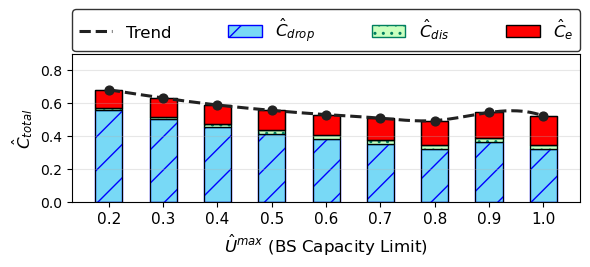

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# ── Config ──
CSV_FILE  = 'output/sweep_umax.csv'
OUT       = 'Graphs_for_paper'
PSI_DROP, PSI_DIS, PSI_E = 0.55, 0.15, 0.30

# ── Load CSV ──
df = pd.read_csv(CSV_FILE)
values = sorted(df['umax'].unique())
proposed = df[df['Algorithm'] == 'Proposed'].set_index('umax').loc[values]

cdrop  = proposed['C_drop'].values  * PSI_DROP
cdis   = proposed['C_dis'].values   * PSI_DIS
ce     = proposed['C_energy'].values * PSI_E
totals = cdrop + cdis + ce

# ── Style ──
_cost_map = {'Drop': r'$\hat{C}_{drop}$', 'Dis': r'$\hat{C}_{dis}$', 'Energy': r'$\hat{C}_{e}$'}
_colors   = {r'$\hat{C}_{drop}$': '#78d9f6', r'$\hat{C}_{dis}$': '#caffbf', r'$\hat{C}_{e}$': 'red'}
_hatches  = {r'$\hat{C}_{drop}$': '/',       r'$\hat{C}_{dis}$': '..',      r'$\hat{C}_{e}$': ''}
_edges    = {r'$\hat{C}_{drop}$': 'blue',    r'$\hat{C}_{dis}$': '#007f5f', r'$\hat{C}_{e}$': '#000000'}

# ── Plot ──
x = np.arange(len(values))
bar_w = 0.5

fig, ax = plt.subplots(figsize=(6, 3))

layers = [
    (cdrop, np.zeros(len(x)),  'Drop'),
    (cdis,  cdrop,             'Dis'),
    (ce,    cdrop + cdis,      'Energy'),
]
for data, bottom, raw_key in layers:
    clabel = _cost_map[raw_key]
    ax.bar(x, data, bar_w, bottom=bottom, label=clabel,
           color=_colors[clabel], hatch=_hatches[clabel],
           edgecolor=_edges[clabel], linewidth=1.0)
    ax.bar(x, data, bar_w, bottom=bottom,
           color='none', edgecolor='k', linewidth=0.8)

# ── Smooth trend line through bar tops ──
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, totals, k=3)
ax.plot(x_smooth, spl(x_smooth), color='#212121', linewidth=2.2,
        linestyle='--', label='Trend', zorder=5)
ax.scatter(x, totals, color='#212121', s=40, zorder=6)

ax.set_xlabel(r'$\hat{U}^{max}$ (BS Capacity Limit)', fontsize=12)
ax.set_ylabel(r'$\hat{C}_{total}$', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in values], fontsize=11)
ax.set_ylim(0, 0.9)
ax.grid(axis='y', alpha=0.3)

handles, lbls = ax.get_legend_handles_labels()
by_label = dict(zip(lbls, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=12,
          bbox_to_anchor=(0, 1.1, 1, 0.2), loc='upper left',
          mode='expand', borderaxespad=0, ncol=4, edgecolor='k')

plt.subplots_adjust(top=0.85)
plt.tight_layout()

import os; os.makedirs(OUT, exist_ok=True)
plt.savefig(f'{OUT}/sweep_umax_breakdown_proposed.pdf', bbox_inches='tight')
plt.savefig(f'{OUT}/sweep_umax_breakdown_proposed.png', bbox_inches='tight', dpi=300)
plt.show()